# Retraining Analysis — Game-Theoretic Convergence
This notebook analyses the results of the iterative retraining loop (run_retraining.py)

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


## Load Results

In [2]:
results_df = pd.read_csv('../results/retraining_results.csv')
print(results_df.head())
print(f"\nAttackers: {results_df['attacker'].unique()}")
print(f"\nModels: {results_df['model'].unique()}")
print(f"\nRounds: {results_df['round'].unique()}")

   round        attacker         model    recall  f1_score  precision  \
0      0  amount_scaling   lr_balanced  0.328431  0.216828   0.161836   
1      0  amount_scaling   rf_balanced  0.487745  0.574315   0.698246   
2      0  amount_scaling  xgb_balanced  0.522059  0.644478   0.841897   
3      0      time_shift   lr_balanced  0.264706  0.178218   0.134328   
4      0      time_shift   rf_balanced  0.181373  0.261023   0.465409   

    roc_auc  
0  0.912348  
1  0.926542  
2  0.915177  
3  0.895007  
4  0.907537  

Attackers: ['amount_scaling' 'time_shift' 'category_mimicry' 'velocity_spacing'
 'combined' 'score_aware_combined']

Models: ['lr_balanced' 'rf_balanced' 'xgb_balanced']

Rounds: [0 1 2 3 4 5 6]


## Convergence Plot: Static vs Adaptive per balanced model

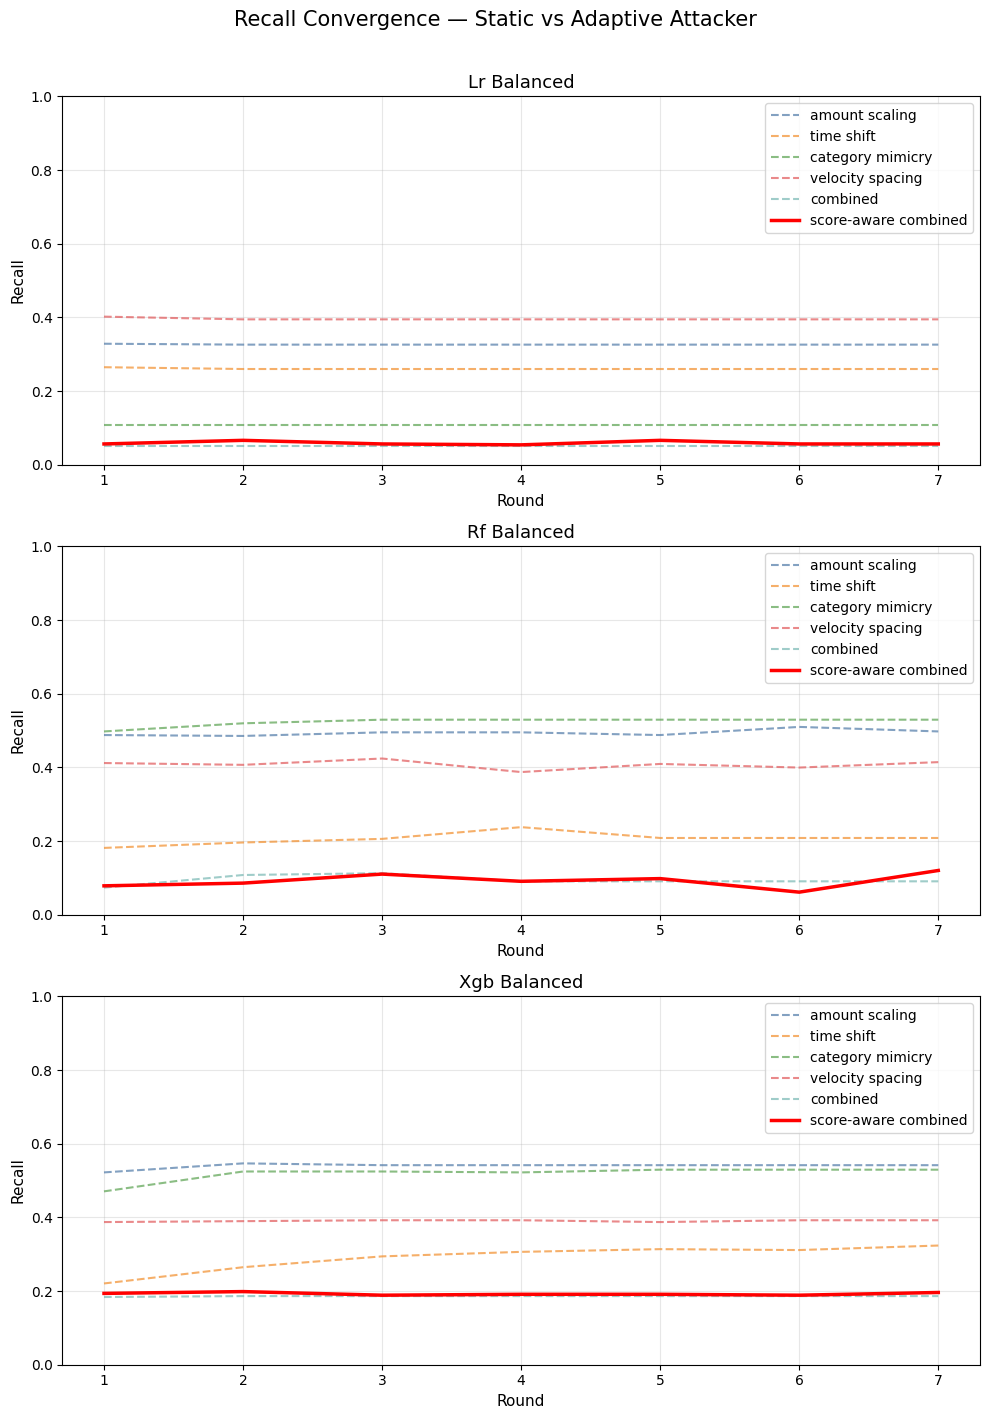

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 14))
balanced_models = ['lr_balanced', 'rf_balanced', 'xgb_balanced']
static_attackers = ['amount_scaling', 'time_shift', 'category_mimicry', 'velocity_spacing', 'combined']
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2']

for i, model_name in enumerate(balanced_models):
    ax = axes[i]
    model_data = results_df[results_df['model'] == model_name]

    # static attackers — dashed lines
    for attacker_name, color in zip(static_attackers, colors):
        attacker_data = model_data[model_data['attacker'] == attacker_name].sort_values('round')
        ax.plot(attacker_data['round'] + 1, attacker_data['recall'],
                label=attacker_name.replace('_', ' '), linestyle='--', alpha=0.7, color=color)

    # score-aware attacker — bold red solid line
    sa_data = model_data[model_data['attacker'] == 'score_aware_combined'].sort_values('round')
    if not sa_data.empty:
        ax.plot(sa_data['round'] + 1, sa_data['recall'],
                label='score-aware combined', linewidth=2.5, color='red', linestyle='-')

    ax.set_title(model_name.replace('_', ' ').title(), fontsize=13)
    ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel('Recall', fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(1, results_df['round'].max() + 2))
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Recall Convergence — Static vs Adaptive Attacker', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('../results/convergence_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## Recall improvement table: round 0 vs round 4 across all model-attacker pairs

In [4]:
all_attackers = static_attackers + ['score_aware_combined']
summary_rows = []

for model_name in results_df['model'].unique():
    for attacker_name in all_attackers:
        subset = results_df[
            (results_df['model'] == model_name) &
            (results_df['attacker'] == attacker_name)
        ].sort_values('round')

        if subset.empty:
            continue

        r0 = subset[subset['round'] == 0]['recall'].values[0]
        r_final = subset.iloc[-1]['recall']
        improvement = r_final - r0

        summary_rows.append({
            'model': model_name,
            'attacker': attacker_name,
            'round_0_recall': round(r0, 3),
            'final_recall': round(r_final, 3),
            'improvement': round(improvement, 3)
        })

summary_df = pd.DataFrame(summary_rows)
print("=== Recall Improvement: Round 0 → Final Round ===")
print(summary_df.to_string(index=False))
summary_df.to_csv('../results/recall_improvement_summary.csv', index=False)

=== Recall Improvement: Round 0 → Final Round ===
       model             attacker  round_0_recall  final_recall  improvement
 lr_balanced       amount_scaling           0.328         0.326       -0.002
 lr_balanced           time_shift           0.265         0.260       -0.005
 lr_balanced     category_mimicry           0.108         0.108        0.000
 lr_balanced     velocity_spacing           0.402         0.395       -0.007
 lr_balanced             combined           0.051         0.051        0.000
 lr_balanced score_aware_combined           0.056         0.056        0.000
 rf_balanced       amount_scaling           0.488         0.498        0.010
 rf_balanced           time_shift           0.181         0.208        0.027
 rf_balanced     category_mimicry           0.498         0.529        0.032
 rf_balanced     velocity_spacing           0.412         0.414        0.002
 rf_balanced             combined           0.074         0.091        0.017
 rf_balanced score_aware_c

## Heatmap: final-round recall across all models and attackers

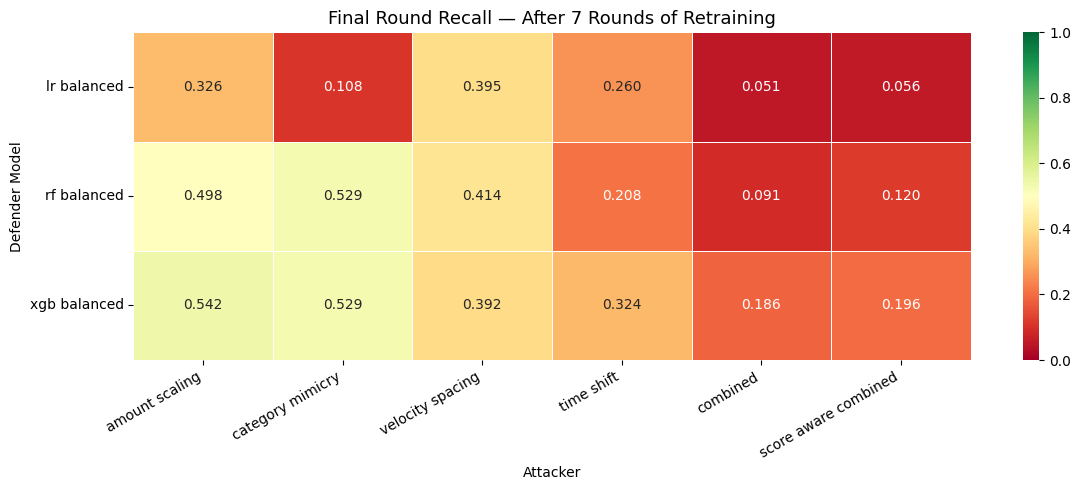

In [5]:
final_round = results_df['round'].max()
final_df = results_df[results_df['round'] == final_round]

heatmap_data = final_df.pivot(index='model', columns='attacker', values='recall')

# order rows and columns sensibly
model_order = ['lr_balanced', 'rf_balanced', 'xgb_balanced']
attacker_order = ['amount_scaling', 'category_mimicry', 'velocity_spacing', 'time_shift', 'combined', 'score_aware_combined']
heatmap_data = heatmap_data.reindex(
    index=[m for m in model_order if m in heatmap_data.index],
    columns=[a for a in attacker_order if a in heatmap_data.columns]
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.3f',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    ax=ax,
    linewidths=0.5
)
ax.set_title(f'Final Round Recall — After {final_round + 1} Rounds of Retraining', fontsize=13)
ax.set_xlabel('Attacker')
ax.set_ylabel('Defender Model')
ax.set_xticklabels([l.get_text().replace('_', ' ') for l in ax.get_xticklabels()], rotation=30, ha='right')
ax.set_yticklabels([l.get_text().replace('_', ' ') for l in ax.get_yticklabels()], rotation=0)
plt.tight_layout()
plt.savefig('../results/final_round_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Equilibrium Analysis: score-aware combined per balanced model

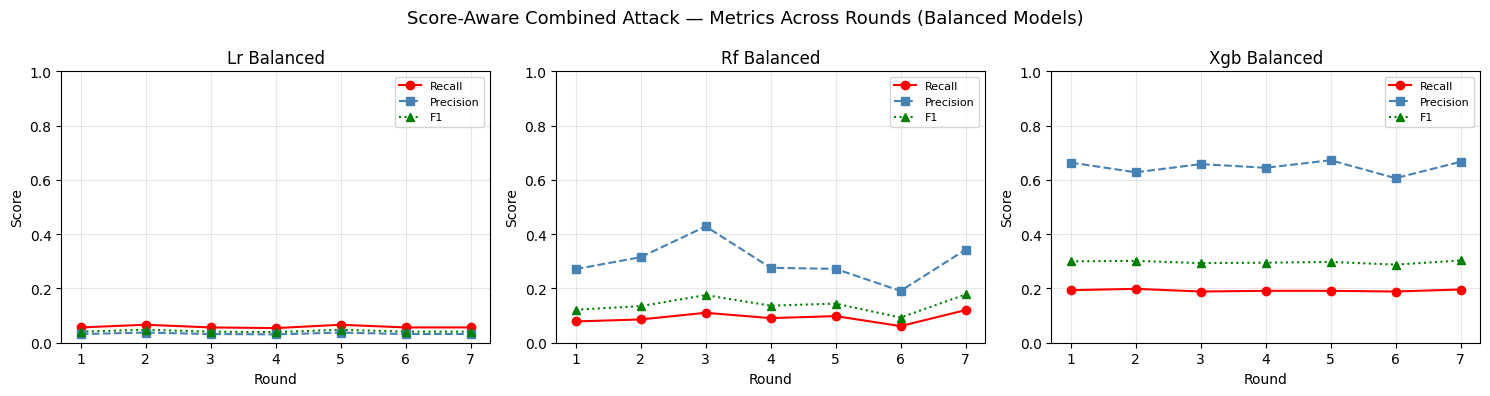

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, model_name in enumerate(balanced_models):
    ax = axes[i]
    sa_data = results_df[
        (results_df['model'] == model_name) &
        (results_df['attacker'] == 'score_aware_combined')
    ].sort_values('round')

    rounds = sa_data['round'] + 1
    ax.plot(rounds, sa_data['recall'], marker='o', label='Recall', color='red')
    ax.plot(rounds, sa_data['precision'], marker='s', label='Precision', color='steelblue', linestyle='--')
    ax.plot(rounds, sa_data['f1_score'], marker='^', label='F1', color='green', linestyle=':')

    ax.set_title(model_name.replace('_', ' ').title())
    ax.set_xlabel('Round')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.set_xticks(rounds)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Score-Aware Combined Attack — Metrics Across Rounds (Balanced Models)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/score_aware_convergence.png', dpi=150, bbox_inches='tight')
plt.show()